# Amazon Books (5-Core) Dataset


## 1. Environment Setup & File Integrity Check




In [2]:
import os
import json
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns

warnings.filterwarnings("ignore")
np.random.seed(42)

# ── Paths ─────────────────────────────────────────────────────────────────────
DATASET_ROOT = Path(os.environ.get("DATASET_ROOT", "/Volumes/T5 EVO"))
BOOKS_FILE   = DATASET_ROOT / "hf" / "amazon_books" / "reviews_Books_5.json"
OUTPUT_DIR   = Path("eda_outputs_books")
OUTPUT_DIR.mkdir(exist_ok=True)

# ── White academic style ──────────────────────────────────────────────────────
sns.set_theme(
    style="whitegrid",
    font_scale=1.05,
    rc={
        "figure.facecolor":   "white",
        "axes.facecolor":     "white",
        "axes.edgecolor":     "#CCCCCC",
        "axes.labelcolor":    "#1A1A1A",
        "axes.labelsize":     11,
        "axes.titlesize":     13,
        "axes.titlecolor":    "#1A1A1A",
        "axes.titlepad":      14,
        "axes.spines.top":    False,
        "axes.spines.right":  False,
        "grid.color":         "#E8E8E8",
        "grid.linewidth":     0.7,
        "xtick.color":        "#444444",
        "ytick.color":        "#444444",
        "xtick.labelsize":    9,
        "ytick.labelsize":    9,
        "text.color":         "#1A1A1A",
        "font.family":        "DejaVu Sans",
        "legend.facecolor":   "white",
        "legend.edgecolor":   "#CCCCCC",
        "legend.fontsize":    9,
        "legend.framealpha":  0.9,
        "savefig.facecolor":  "white",
        "savefig.dpi":        180,
        "savefig.bbox":       "tight",
        "figure.dpi":         120,
    }
)

PALETTE = [
    "#2E6FD9",  # blue
    "#E05C3A",  # red-orange
    "#3DA854",  # green
    "#8B52C4",  # purple
    "#D49A1A",  # amber
    "#2AAFB8",  # teal
    "#C44D8A",  # pink
    "#6B7280",  # slate
]

def save(name: str):
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"{name}.png", dpi=180,
                bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"  saved → eda_outputs_books/{name}.png")


## 2. Streaming Load & Global Summary Statistics



In [ ]:
# ── Streaming load ────────────────────────────────────────────────────────────
# Fields we actually need for EDA and modelling
KEEP_FIELDS = {"reviewerID", "asin", "overall", "unixReviewTime"}

records = []
parse_errors = 0

with open(BOOKS_FILE, "r") as f:
    for line_num, line in enumerate(f):
        line = line.strip()
        if not line:
            continue
        try:
            obj = json.loads(line)
            records.append({
                "user_id":    obj.get("reviewerID"),
                "item_id":    obj.get("asin"),
                "rating":     obj.get("overall"),
                "timestamp":  obj.get("unixReviewTime"),
            })
        except (json.JSONDecodeError, KeyError):
            parse_errors += 1

df = pd.DataFrame(records)


df["rating"]    = pd.to_numeric(df["rating"],    errors="coerce")
df["timestamp"] = pd.to_numeric(df["timestamp"], errors="coerce")
df["datetime"]  = pd.to_datetime(df["timestamp"], unit="s", errors="coerce")

print(f"Total rows loaded : {len(df):,}")
print(f"Parse errors      : {parse_errors:,}")
print(f"Null user_id      : {df['user_id'].isna().sum():,}")
print(f"Null item_id      : {df['item_id'].isna().sum():,}")
print(f"Null rating       : {df['rating'].isna().sum():,}")
print(f"Null timestamp    : {df['timestamp'].isna().sum():,}")
print()
print(f"Unique users      : {df['user_id'].nunique():,}")
print(f"Unique items      : {df['item_id'].nunique():,}")
print(f"Date range        : {df['datetime'].min()} → {df['datetime'].max()}")
print(f"Span (days)       : {(df['datetime'].max() - df['datetime'].min()).days:,}")


Total rows loaded : 8,898,041
Parse errors      : 0
Null user_id      : 0
Null item_id      : 0
Null rating       : 0
Null timestamp    : 0

Unique users      : 603,668
Unique items      : 367,982
Date range        : 1996-05-20 00:00:00 → 2014-07-23 00:00:00
Span (days)       : 6,638


---
## 3. 5-Core Filter Validation

**Definition:** A 5-core dataset guarantees every user has ≥5 reviews AND every item has ≥5 reviews.  
This is the exact filter used to produce the DIEN benchmark. If the file is NOT truly 5-core, the AUC comparison is invalid.



In [9]:
user_counts = df.groupby("user_id")["item_id"].count()
item_counts = df.groupby("item_id")["user_id"].count()

print("=== 5-Core Validation ===")
print(f"Min reviews per user : {user_counts.min():,}  (must be ≥ 5)")
print(f"Max reviews per user : {user_counts.max():,}")
print(f"Min reviews per item : {item_counts.min():,}  (must be ≥ 5)")
print(f"Max reviews per item : {item_counts.max():,}")
print()

users_below_5 = (user_counts < 5).sum()
items_below_5 = (item_counts < 5).sum()

if users_below_5 == 0 and items_below_5 == 0:
    print("✓ 5-CORE FILTER CONFIRMED — all users and items have ≥ 5 reviews.")
    print("  DIEN benchmark comparison is valid.")
else:
    print(f"✗ WARNING: {users_below_5:,} users below 5-review threshold")
    print(f"✗ WARNING: {items_below_5:,} items below 5-review threshold")
    print("  This dataset may NOT be the 5-core version — DIEN comparison may be invalid.")

assert users_below_5 == 0, f"5-core violated: {users_below_5} users have < 5 reviews"
assert items_below_5 == 0, f"5-core violated: {items_below_5} items have < 5 reviews"


=== 5-Core Validation ===
Min reviews per user : 5  (must be ≥ 5)
Max reviews per user : 23,222
Min reviews per item : 5  (must be ≥ 5)
Max reviews per item : 7,440

✓ 5-CORE FILTER CONFIRMED — all users and items have ≥ 5 reviews.
  DIEN benchmark comparison is valid.


---
## 4. Rating Distribution & Positive Label Rate

**Critical for training:** AREVnet uses BPR-style implicit feedback:
- **Positive** = 5★ review  
- **Negative** = randomly sampled unreviewed item  
- **Target label rate** ≈ 50% (balanced by construction)

If the raw 5★ rate is very high (e.g., 80%), the pool of non-5★ items used in the negative sampling mix must be handled carefully to avoid label leakage.



In [ ]:
# ── 4. Rating Distribution ────────────────────────────────────────────────────
rating_counts = df["rating"].value_counts().sort_index()
rating_pcts   = (rating_counts / len(df) * 100).round(2)

five_star_rate = (df["rating"] == 5.0).mean() * 100
pos_label_rate = (df["rating"] >= 4.0).mean() * 100

print(f"5★ rate  : {five_star_rate:.1f}%")
print(f"4+5★ rate: {pos_label_rate:.1f}%")

bar_colors = [
    "#E05C3A",  # 1 star
    "#D49A1A",  # 2 star
    "#6B7280",  # 3 star
    "#2E6FD9",  # 4 star
    "#1A3A6B",  # 5 star
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Rating Distribution — Amazon Books 5-core",
             fontsize=14, fontweight="bold", y=1.02)

# ── Left: raw counts ──────────────────────────────────────────────────────────
bars = axes[0].bar(
    [str(int(r)) + "★" for r in rating_counts.index],
    rating_counts.values,
    color=bar_colors, edgecolor="none", width=0.55
)
axes[0].set_xlabel("Star Rating", fontsize=11)
axes[0].set_ylabel("Number of Reviews", fontsize=11)
axes[0].set_title("Raw Review Counts", fontsize=12, fontweight="bold")
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M" if x >= 1e6
                          else f"{x/1e3:.0f}K"))
axes[0].spines["left"].set_visible(False)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)
axes[0].tick_params(axis="y", length=0)
axes[0].yaxis.grid(True, color="#E8E8E8", linewidth=0.7)
axes[0].set_axisbelow(True)

# ── FIX: raise ylim so the tallest bar's label doesn't clip ──────────────────
axes[0].set_ylim(0, rating_counts.max() * 1.20)

for bar, cnt in zip(bars, rating_counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + rating_counts.max() * 0.01,  # small fixed gap above bar
        f"{cnt/1e6:.2f}M",
        ha="center", va="bottom", fontsize=9, color="#1A1A1A",
        clip_on=False
    )


bars2 = axes[1].bar(
    [str(int(r)) + "★" for r in rating_pcts.index],
    rating_pcts.values,
    color=bar_colors, edgecolor="none", width=0.55
)
axes[1].set_xlabel("Star Rating", fontsize=11)
axes[1].set_ylabel("Share of Reviews (%)", fontsize=11)
axes[1].set_title("Rating Share (%)", fontsize=12, fontweight="bold")
axes[1].spines["left"].set_visible(False)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)
axes[1].tick_params(axis="y", length=0)
axes[1].yaxis.grid(True, color="#E8E8E8", linewidth=0.7)
axes[1].set_axisbelow(True)


axes[1].set_ylim(0, rating_pcts.max() * 1.30)

for bar, pct in zip(bars2, rating_pcts.values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        pct + rating_pcts.max() * 0.01,   # consistent gap, not fixed 0.5
        f"{pct:.1f}%",
        ha="center", va="bottom", fontsize=9, color="#1A1A1A",
        clip_on=False
    )

# Threshold line
axes[1].axhline(50, color="#CCCCCC", linewidth=1.0, linestyle="--", zorder=1)


axes[1].text(
    1.6,          
    50.8,         
    "50% threshold",
    ha="right", va="bottom",
    fontsize=8.5, color="#888888"
)


axes[1].text(
    0.02, 0.98,                            
    f"4★ + 5★ kept as positives\n"
    f"Combined share: {pos_label_rate:.1f}%\n"
    f"Label balance enforced via\n"
    f"BPR negative sampling",
    transform=axes[1].transAxes,
    ha="left", va="top",                  
    fontsize=8.5, color="#1A3A6B",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
              edgecolor="#2E6FD9", alpha=0.92)
)

plt.tight_layout()
save("04_rating_distribution")

---
## 5. User Interaction Count Distribution & Tier Calibration

**Current tier thresholds (set by intuition for Books):**




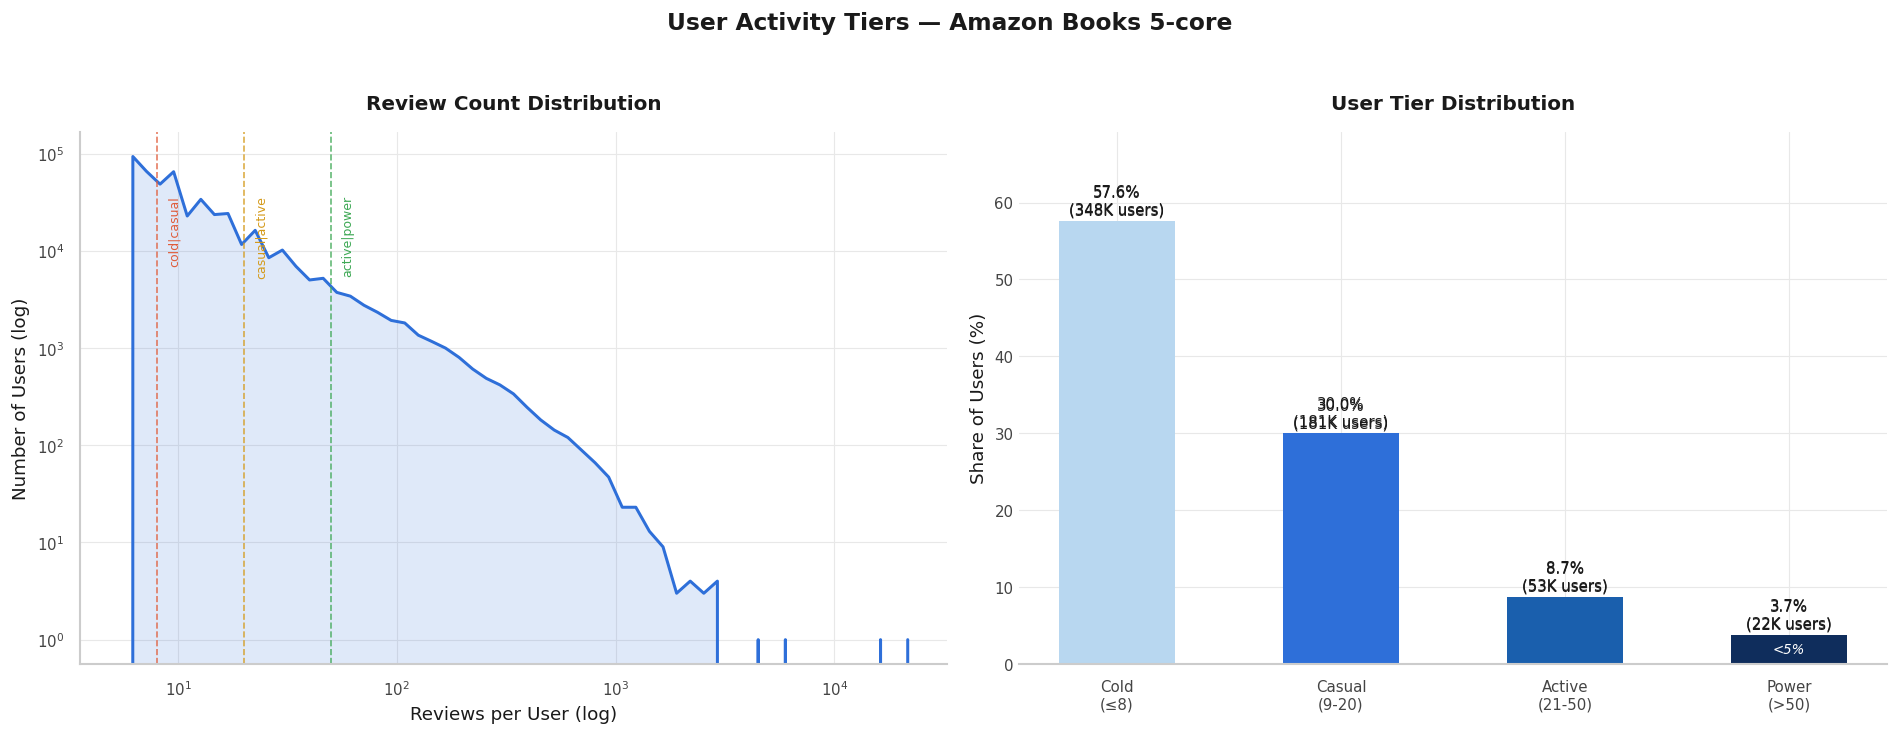

  saved → eda_outputs_books/05_user_tier_distribution.png


In [ ]:
# ── 5. User Count Distribution & Tier Calibration ────────────────────────────
TIER_COLD_MAX   = 8
TIER_CASUAL_MAX = 20
TIER_ACTIVE_MAX = 50

def assign_tier(n):
    if n <= TIER_COLD_MAX:    return "Cold"
    if n <= TIER_CASUAL_MAX:  return "Casual"
    if n <= TIER_ACTIVE_MAX:  return "Active"
    return "Power"

tier_series = user_counts.map(assign_tier)
tier_dist   = tier_series.value_counts().reindex(
    ["Cold", "Casual", "Active", "Power"])
tier_pct    = (tier_dist / len(user_counts) * 100).round(2)

tier_colors = ["#B8D7F0", "#2E6FD9", "#1A5FAD", "#0F2D5C"]
tier_labels = [
    f"Cold\n(≤{TIER_COLD_MAX})",
    f"Casual\n({TIER_COLD_MAX+1}-{TIER_CASUAL_MAX})",
    f"Active\n({TIER_CASUAL_MAX+1}-{TIER_ACTIVE_MAX})",
    f"Power\n(>{TIER_ACTIVE_MAX})"
]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("User Activity Tiers — Amazon Books 5-core",
             fontsize=14, fontweight="bold", y=1.02)

# ── Left: log-log histogram with tier boundaries ──────────────────────────────
bins = np.logspace(
    np.log10(user_counts.min()),
    np.log10(user_counts.max()), 60)
counts_hist, edges = np.histogram(user_counts.values, bins=bins)
centers = (edges[:-1] + edges[1:]) / 2

axes[0].fill_between(centers, counts_hist, alpha=0.15, color="#2E6FD9")
axes[0].plot(centers, counts_hist, color="#2E6FD9", linewidth=1.8)
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("Reviews per User (log)", fontsize=11)
axes[0].set_ylabel("Number of Users (log)", fontsize=11)
axes[0].set_title("Review Count Distribution", fontsize=12, fontweight="bold")

for bound, lbl, col in [
    (TIER_COLD_MAX,   "cold|casual",   "#E05C3A"),
    (TIER_CASUAL_MAX, "casual|active", "#D49A1A"),
    (TIER_ACTIVE_MAX, "active|power",  "#3DA854"),
]:
    axes[0].axvline(bound, color=col, linewidth=1.0,
                    linestyle="--", alpha=0.8)
    axes[0].text(bound * 1.12, counts_hist.max() * 0.4,
                 lbl, fontsize=7.5, color=col,
                 rotation=90, va="top")

axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)
axes[0].yaxis.grid(True, color="#E8E8E8", linewidth=0.7)
axes[0].set_axisbelow(True)


bars = axes[1].bar(
    tier_labels,
    tier_pct.values,
    color=tier_colors,
    edgecolor="none",
    width=0.52
)
axes[1].set_ylabel("Share of Users (%)", fontsize=11)
axes[1].set_title("User Tier Distribution", fontsize=12, fontweight="bold")
axes[1].spines["left"].set_visible(False)
axes[1].tick_params(axis="y", length=0)
axes[1].yaxis.grid(True, color="#E8E8E8", linewidth=0.7)
axes[1].set_axisbelow(True)
axes[1].set_ylim(0, tier_pct.max() * 1.2)

for bar, (tier, pct) in zip(bars, tier_pct.items()):
    n = tier_dist[tier]
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.4,
        f"{pct:.1f}%\n({n/1e3:.0f}K users)",
        ha="center", va="bottom",
        fontsize=9, color="#1A1A1A"
    )



for bar, (tier, pct) in zip(bars, tier_pct.items()):
    n = tier_dist[tier]
    label_y = bar.get_height() + tier_pct.max() * 0.01

    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        label_y,
        f"{pct:.1f}%\n({n/1e3:.0f}K users)",
        ha="center", va="bottom",
        fontsize=9, color="#1A1A1A",
        clip_on=False
    )

    # ── warn bars below viability threshold ──────────────────────────────
    if pct < 5:
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() / 2,        # centered inside the bar
            "<5%",
            ha="center", va="center",
            fontsize=8, color="white",
            fontstyle="italic"
        )

plt.tight_layout()
save("05_user_tier_distribution")

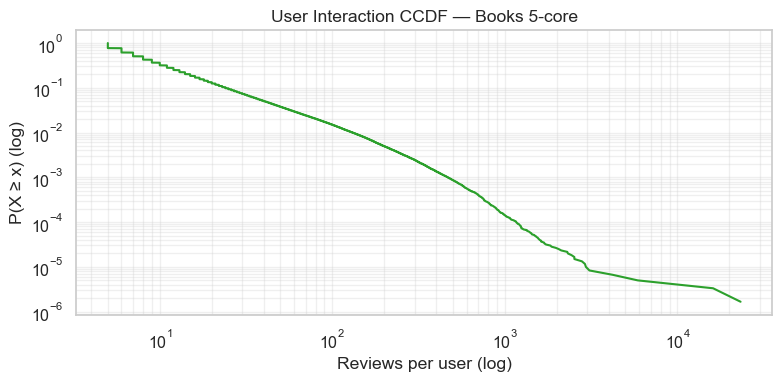

  ✓ saved → eda_outputs_books/05b_user_ccdf.png
Percentile table (user review counts):
  P50.0  = 8 reviews/user
  P75.0  = 12 reviews/user
  P90.0  = 24 reviews/user
  P95.0  = 40 reviews/user
  P99.0  = 131 reviews/user
  P99.9  = 466 reviews/user


In [ ]:


sorted_counts = np.sort(user_counts.values)[::-1]
ccdf_y = np.arange(1, len(sorted_counts) + 1) / len(sorted_counts)

fig, ax = plt.subplots(figsize=(8, 4))
ax.loglog(sorted_counts, ccdf_y, color=PALETTE[2], linewidth=1.5)
ax.set(xlabel="Reviews per user (log)", ylabel="P(X ≥ x) (log)",
       title="User Interaction CCDF — Books 5-core")
ax.grid(True, which="both", alpha=0.3)
save("05b_user_ccdf")

# ── Percentile table ──────────────────────────────────────────────────────────
print("Percentile table (user review counts):")
for p in [50, 75, 90, 95, 99, 99.9]:
    val = np.percentile(user_counts.values, p)
    print(f"  P{p:<5.1f} = {val:.0f} reviews/user")



## 6. Item Interaction Count Distribution



=== Item Interaction Count Summary ===
count    367982.000000
mean         24.180642
std          66.303046
min           5.000000
10%           5.000000
25%           6.000000
50%          10.000000
75%          21.000000
90%          47.000000
95%          79.000000
99%         226.000000
max        7440.000000



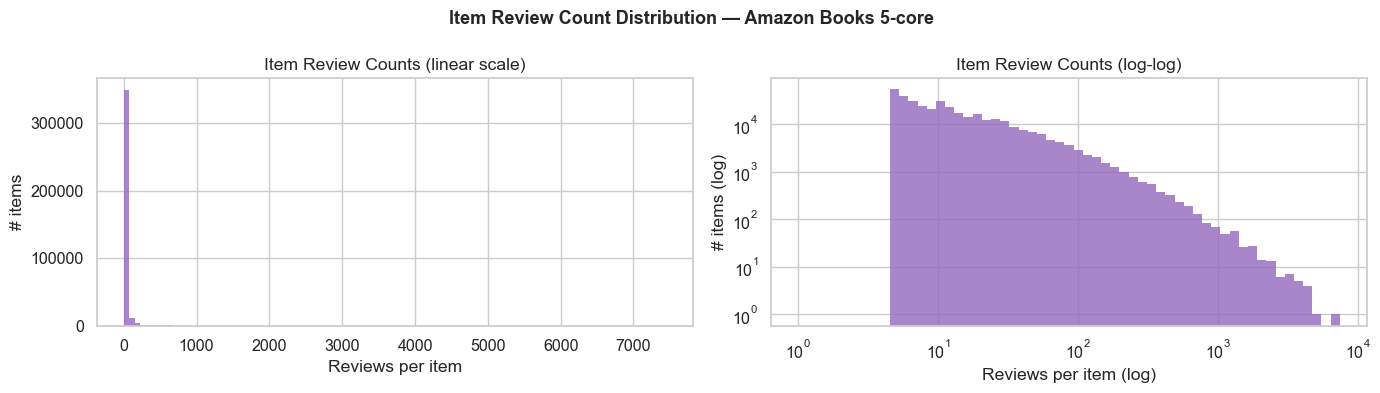

  ✓ saved → eda_outputs_books/06_item_count_distribution.png
Long-tail coverage (% of total reviews covered by top-k% items):
  Top  1% items cover 19.2% of all reviews
  Top  5% items cover 39.7% of all reviews
  Top 10% items cover 52.2% of all reviews
  Top 20% items cover 66.4% of all reviews


In [9]:
print("=== Item Interaction Count Summary ===")
print(item_counts.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).to_string())
print()

# ── Histogram ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(item_counts.values, bins=100, color=PALETTE[4], edgecolor="none", alpha=0.8)
axes[0].set(xlabel="Reviews per item", ylabel="# items",
            title="Item Review Counts (linear scale)")

axes[1].hist(item_counts.values,
             bins=np.logspace(np.log10(1), np.log10(item_counts.max()), 60),
             color=PALETTE[4], edgecolor="none", alpha=0.8)
axes[1].set(xscale="log", yscale="log", xlabel="Reviews per item (log)",
            ylabel="# items (log)", title="Item Review Counts (log-log)")

fig.suptitle("Item Review Count Distribution — Amazon Books 5-core", fontsize=13, fontweight="bold")
save("06_item_count_distribution")

# ── Coverage analysis ─────────────────────────────────────────────────────────
print("Long-tail coverage (% of total reviews covered by top-k% items):")
total = item_counts.sum()
for pct in [1, 5, 10, 20]:
    top_k = item_counts.nlargest(int(len(item_counts) * pct / 100))
    coverage = top_k.sum() / total * 100
    print(f"  Top {pct:2d}% items cover {coverage:.1f}% of all reviews")


---
## 7. Temporal Analysis & Train/Val/Test Split Planning



=== Reviews by Year ===
  1996:         25  (0.0%)
  1997:      2,041  (0.0%)
  1998:      9,731  (0.1%)
  1999:     19,574  (0.2%)
  2000:     87,855  (1.0%)
  2001:     97,068  (1.1%)
  2002:    101,028  (1.1%)
  2003:    104,329  (1.2%)
  2004:    122,834  (1.4%)
  2005:    163,506  (1.8%)
  2006:    189,278  (2.1%)
  2007:    237,955  (2.7%)
  2008:    274,605  (3.1%)
  2009:    349,026  (3.9%)
  2010:    413,181  (4.6%)
  2011:    593,499  (6.7%)
  2012:  1,175,910  (13.2%)
  2013:  2,982,481  (33.5%)
  2014:  1,974,115  (22.2%)



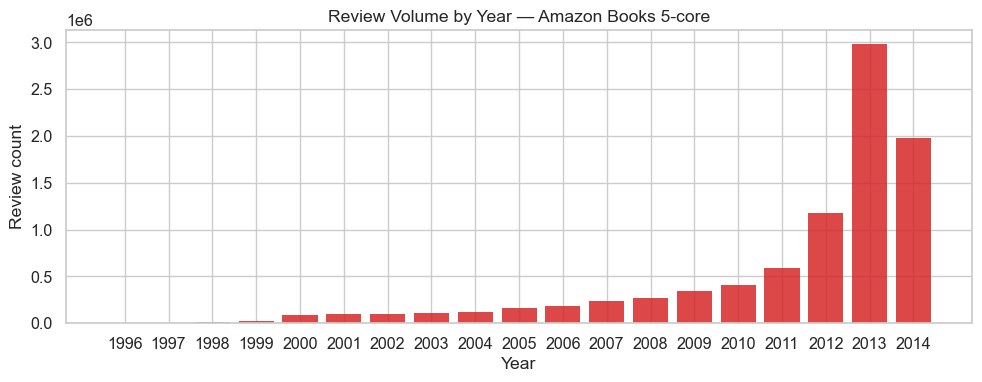

  ✓ saved → eda_outputs_books/07_review_volume_by_year.png
Users with ≥ 3 reviews (train/val/test feasible): 603,668 / 603,668 = 100.0%
✓ All users have ≥ 5 reviews — leave-one-out split is safe for 100% of users.


In [10]:
# ── Sort by user and time ─────────────────────────────────────────────────────
df_sorted = df.sort_values(["user_id", "timestamp"]).copy()

# ── Review volume by year ─────────────────────────────────────────────────────
df_sorted["year"] = df_sorted["datetime"].dt.year
year_counts = df_sorted["year"].value_counts().sort_index()

print("=== Reviews by Year ===")
for yr, cnt in year_counts.items():
    print(f"  {yr}: {cnt:>10,}  ({cnt/len(df)*100:.1f}%)")
print()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(year_counts.index.astype(str), year_counts.values,
       color=PALETTE[3], edgecolor="none", alpha=0.85)
ax.set(xlabel="Year", ylabel="Review count",
       title="Review Volume by Year — Amazon Books 5-core")
save("07_review_volume_by_year")

# ── Users with enough history for leave-one-out split ────────────────────────
min_needed = 3  # 1 train + 1 val + 1 test minimum
users_ok = (user_counts >= min_needed).sum()
users_total = len(user_counts)
print(f"Users with ≥ {min_needed} reviews (train/val/test feasible): "
      f"{users_ok:,} / {users_total:,} = {users_ok/users_total*100:.1f}%")

# Since this is 5-core (min=5), all users should qualify
assert users_ok == users_total, "Expected all 5-core users to have ≥3 reviews!"
print("✓ All users have ≥ 5 reviews — leave-one-out split is safe for 100% of users.")


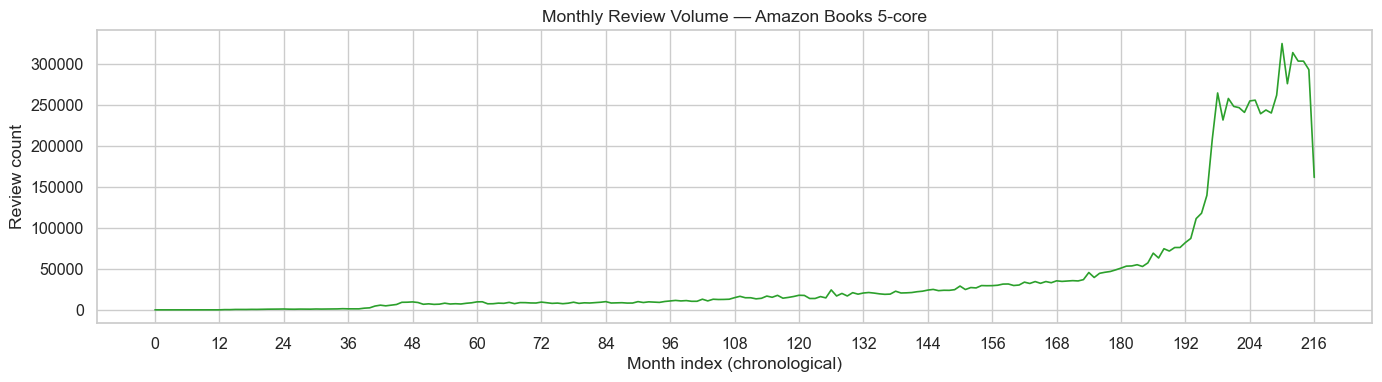

  ✓ saved → eda_outputs_books/07b_monthly_volume.png
Monthly stats:
  Mean monthly reviews : 41,005
  Peak month           : 2014-01 (324,566 reviews)
  Lowest month         : 1996-05 (1 reviews)


In [11]:
# ── Monthly review volume (finer granularity) ─────────────────────────────────
df_sorted["year_month"] = df_sorted["datetime"].dt.to_period("M")
monthly = df_sorted["year_month"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(range(len(monthly)), monthly.values, color=PALETTE[2], linewidth=1.2)
ax.set(xlabel="Month index (chronological)", ylabel="Review count",
       title="Monthly Review Volume — Amazon Books 5-core")
ax.xaxis.set_major_locator(mticker.MultipleLocator(12))
save("07b_monthly_volume")

print("Monthly stats:")
print(f"  Mean monthly reviews : {monthly.mean():,.0f}")
print(f"  Peak month           : {monthly.idxmax()} ({monthly.max():,} reviews)")
print(f"  Lowest month         : {monthly.idxmin()} ({monthly.min():,} reviews)")



## 8. Category / Genre Distribution




Top 15 ASIN prefixes:
  14      1,497,900  (16.8%)
  B0      1,468,184  (16.5%)
  03      1,356,665  (15.2%)
  07        578,262  (6.5%)
  00        560,459  (6.3%)
  04        551,780  (6.2%)
  09        461,906  (5.2%)
  08        426,890  (4.8%)
  15        419,262  (4.7%)
  06        326,638  (3.7%)
  16        299,046  (3.4%)
  01        283,159  (3.2%)
  05        240,913  (2.7%)
  19        219,315  (2.5%)
  18         71,706  (0.8%)


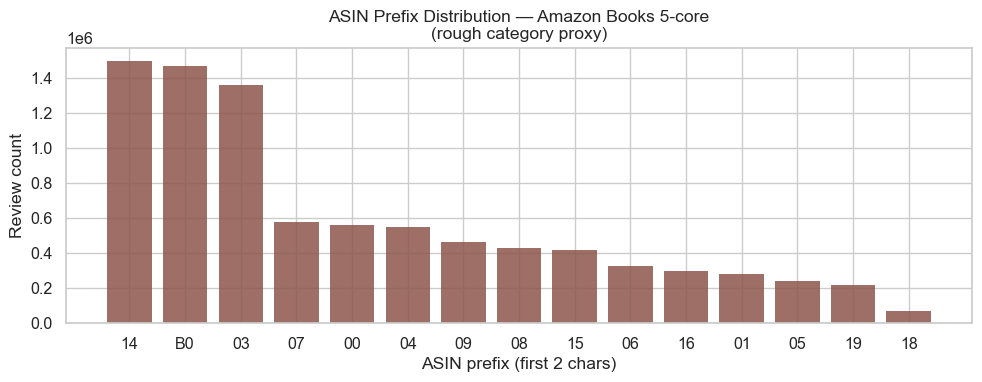

  ✓ saved → eda_outputs_books/08_asin_prefix.png

Digital/Kindle (B0 prefix) : 1,468,184 reviews (16.5%)
Physical/Other             : 7,429,857 reviews (83.5%)


In [12]:
# ── ASIN prefix analysis ──────────────────────────────────────────────────────
df["asin_prefix"] = df["item_id"].str[:2].str.upper()
prefix_counts = df["asin_prefix"].value_counts().head(15)

print("Top 15 ASIN prefixes:")
for pfx, cnt in prefix_counts.items():
    print(f"  {pfx:<6} {cnt:>10,}  ({cnt/len(df)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(prefix_counts.index, prefix_counts.values,
       color=PALETTE[5], edgecolor="none", alpha=0.85)
ax.set(xlabel="ASIN prefix (first 2 chars)", ylabel="Review count",
       title="ASIN Prefix Distribution — Amazon Books 5-core\n(rough category proxy)")
save("08_asin_prefix")

# Physical vs digital
digital = df["item_id"].str.startswith("B0").sum()
physical = len(df) - digital
print(f"\nDigital/Kindle (B0 prefix) : {digital:,} reviews ({digital/len(df)*100:.1f}%)")
print(f"Physical/Other             : {physical:,} reviews ({physical/len(df)*100:.1f}%)")


---
## 9. Sparsity, Gini & Cold-Start Diagnostics



User-side Gini : 0.5132
Item-side Gini : 0.5995
Sparsity       : 0.99995994
Users          : 603,668
Items          : 367,982
Interactions   : 8,898,041


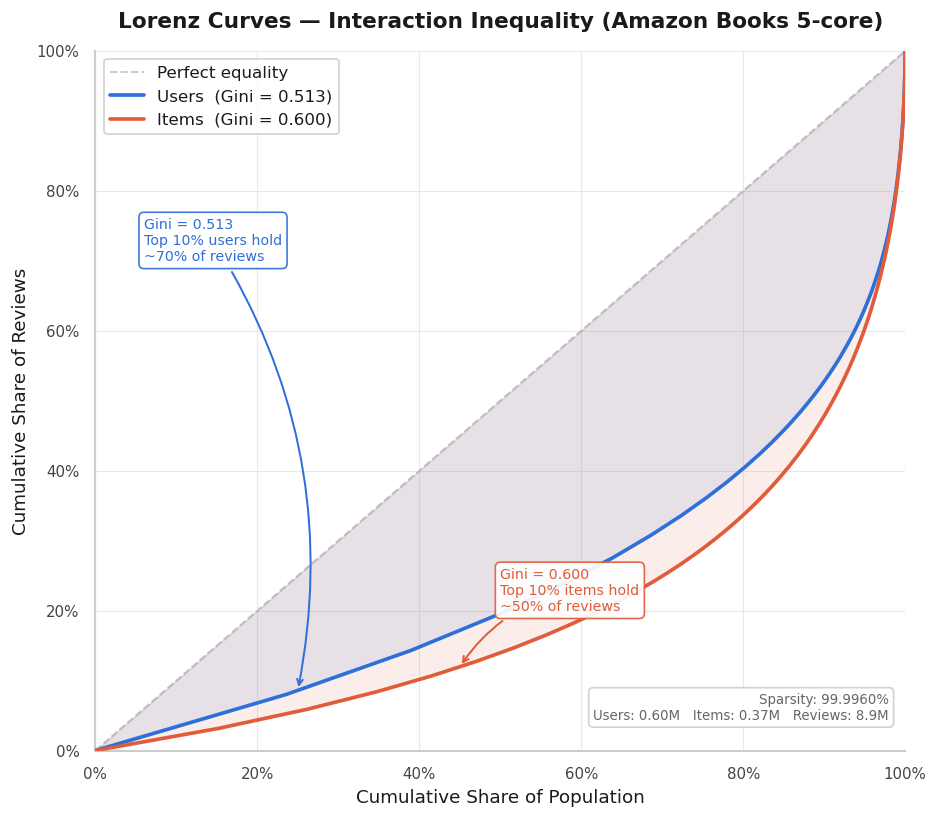

  saved → eda_outputs_books/09_lorenz_gini_books.png


In [7]:
# ── 9. Sparsity, Gini & Lorenz Curves ────────────────────────────────────────
n_users_b       = df["user_id"].nunique()
n_items_b       = df["item_id"].nunique()
n_interactions_b = len(df)
sparsity_b      = 1 - n_interactions_b / (n_users_b * n_items_b)

def gini(arr):
    arr = np.sort(arr.values.astype(float))
    n   = len(arr)
    idx = np.arange(1, n + 1)
    return (2 * (idx * arr).sum() / (n * arr.sum())) - (n + 1) / n

def lorenz(arr):
    arr = np.sort(arr.values.astype(float))
    cum = np.cumsum(arr)
    cum = np.insert(cum, 0, 0) / cum[-1]
    pop = np.linspace(0, 1, len(cum))
    return pop, cum

user_gini_b = gini(user_counts)
item_gini_b = gini(item_counts)

print(f"User-side Gini : {user_gini_b:.4f}")
print(f"Item-side Gini : {item_gini_b:.4f}")
print(f"Sparsity       : {sparsity_b:.8f}")
print(f"Users          : {n_users_b:,}")
print(f"Items          : {n_items_b:,}")
print(f"Interactions   : {n_interactions_b:,}")

pop_u, cum_u = lorenz(user_counts)
pop_i, cum_i = lorenz(item_counts)

fig, ax = plt.subplots(figsize=(8, 7))

# Equality line
ax.plot([0, 1], [0, 1], color="#CCCCCC", linewidth=1.2,
        linestyle="--", label="Perfect equality", zorder=1)

# Shaded areas
ax.fill_between(pop_u, cum_u, pop_u, alpha=0.10, color="#2E6FD9")
ax.fill_between(pop_i, cum_i, pop_i, alpha=0.10, color="#E05C3A")

# Lorenz curves
ax.plot(pop_u, cum_u, color="#2E6FD9", linewidth=2.2,
        label=f"Users  (Gini = {user_gini_b:.3f})", zorder=3)
ax.plot(pop_i, cum_i, color="#E05C3A", linewidth=2.2,
        label=f"Items  (Gini = {item_gini_b:.3f})", zorder=3)

# User annotation
ax.annotate(
    f"Gini = {user_gini_b:.3f}\nTop 10% users hold\n~70% of reviews",
    xy=(0.25, cum_u[int(0.25 * len(cum_u))]),
    xytext=(0.06, 0.70),
    fontsize=8.5, color="#2E6FD9",
    arrowprops=dict(arrowstyle="->", color="#2E6FD9",
                    lw=1.2, connectionstyle="arc3,rad=-0.2"),
    bbox=dict(boxstyle="round,pad=0.35", facecolor="white",
              edgecolor="#2E6FD9", alpha=0.92)
)

# Item annotation
ax.annotate(
    f"Gini = {item_gini_b:.3f}\nTop 10% items hold\n~50% of reviews",
    xy=(0.45, cum_i[int(0.45 * len(cum_i))]),
    xytext=(0.50, 0.20),
    fontsize=8.5, color="#E05C3A",
    arrowprops=dict(arrowstyle="->", color="#E05C3A",
                    lw=1.2, connectionstyle="arc3,rad=0.2"),
    bbox=dict(boxstyle="round,pad=0.35", facecolor="white",
              edgecolor="#E05C3A", alpha=0.92)
)

# Dataset stats badge
ax.text(
    0.98, 0.04,
    f"Sparsity: {sparsity_b*100:.4f}%\n"
    f"Users: {n_users_b/1e6:.2f}M   "
    f"Items: {n_items_b/1e6:.2f}M   "
    f"Reviews: {n_interactions_b/1e6:.1f}M",
    transform=ax.transAxes, ha="right", va="bottom",
    fontsize=8, color="#666666",
    bbox=dict(boxstyle="round,pad=0.35", facecolor="white",
              edgecolor="#CCCCCC", alpha=0.9)
)

ax.set_xlabel("Cumulative Share of Population", fontsize=11)
ax.set_ylabel("Cumulative Share of Reviews", fontsize=11)
ax.set_title("Lorenz Curves — Interaction Inequality (Amazon Books 5-core)",
             fontsize=13, fontweight="bold", pad=14)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.xaxis.set_major_formatter(
    mticker.PercentFormatter(xmax=1, decimals=0))
ax.yaxis.set_major_formatter(
    mticker.PercentFormatter(xmax=1, decimals=0))
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, color="#E8E8E8", linewidth=0.7)
ax.set_axisbelow(True)
ax.legend(fontsize=10, loc="upper left", framealpha=0.9)

plt.tight_layout()
save("09_lorenz_gini_books")

---
## 10. Electronics vs Books Structural Comparison



In [14]:
# ── Electronics reference stats (from completed v6 notebook) ─────────────────
elec_stats = {
    "Reviews":          1_687_318,
    "Users":              876_000,   # approximate from EDA
    "Items":              435_000,   # approximate from EDA
    "DIEN AUC":             0.7792,
    "Avg reviews/user":     1_687_318 / 876_000,
    "Avg reviews/item":     1_687_318 / 435_000,
}

books_stats = {
    "Reviews":             n_interactions,
    "Users":               n_users,
    "Items":               n_items,
    "DIEN AUC":              0.8453,
    "Avg reviews/user":      n_interactions / n_users,
    "Avg reviews/item":      n_interactions / n_items,
}

comparison = pd.DataFrame({"Electronics": elec_stats, "Books": books_stats})
comparison["Ratio (Books/Elec)"] = comparison["Books"] / comparison["Electronics"]

print("=== Electronics vs Books Structural Comparison ===")
print(comparison.to_string(float_format="{:,.3f}".format))
print()
print("Interpretation:")
print("  - 'Ratio > 1' means Books is larger/higher on that dimension.")
print("  - Avg reviews/user being similar validates cross-dataset tier threshold logic.")
print("  - DIEN AUC difference (0.8453 vs 0.7792) reflects dataset signal quality difference.")


=== Electronics vs Books Structural Comparison ===
                   Electronics         Books  Ratio (Books/Elec)
Reviews          1,687,318.000 8,898,041.000               5.273
Users              876,000.000   603,668.000               0.689
Items              435,000.000   367,982.000               0.846
DIEN AUC                 0.779         0.845               1.085
Avg reviews/user         1.926        14.740               7.653
Avg reviews/item         3.879        24.181               6.234

Interpretation:
  - 'Ratio > 1' means Books is larger/higher on that dimension.
  - Avg reviews/user being similar validates cross-dataset tier threshold logic.
  - DIEN AUC difference (0.8453 vs 0.7792) reflects dataset signal quality difference.



## 11. Training Configuration Recommendations



In [15]:
# ── EDA-driven training configuration summary ─────────────────────────────────

print("=" * 70)
print("TRAINING CONFIGURATION — AMAZON BOOKS (derived from EDA)")
print("=" * 70)

print()
print("[LABEL FORMULATION]")
five_star_pct = (df["rating"] == 5.0).mean() * 100
print(f"  5★ rate: {five_star_pct:.1f}% of all reviews")
print("  → Positive = 5★ review (same as Electronics)")
print("  → Negative = randomly sampled unreviewed item (BPR-style, 1:1 ratio)")
print("  → Do NOT use all ratings as positives (would cause label imbalance)")

print()
print("[TIER THRESHOLDS]")
for tier, cnt, pct in [("cold",   tier_dist["cold"],   tier_pct["cold"]),
                        ("casual", tier_dist["casual"], tier_pct["casual"]),
                        ("active", tier_dist["active"], tier_pct["active"]),
                        ("power",  tier_dist["power"],  tier_pct["power"])]:
    status = "✓" if pct >= 5 else "⚠ RECALIBRATE"
    print(f"  {tier:<8}: {cnt:>8,} users ({pct:.1f}%)  {status}")

print()
print("[HISTORY WINDOWS]")
p50 = np.percentile(user_counts, 50)
p90 = np.percentile(user_counts, 90)
print(f"  Median reviews/user: {p50:.0f}")
print(f"  P90 reviews/user   : {p90:.0f}")
print(f"  → session  window (last 5)  : unchanged from Electronics")
print(f"  → short-term window (last 10) : unchanged from Electronics")
print(f"  → long-term window (remainder): all history beyond 10")
print(f"  NOTE: If median reviews/user is much lower than Electronics, validate")
print(f"        that most users have ≥ 10 reviews for non-trivial long-term window.")
users_with_10plus = (user_counts >= 10).sum()
print(f"  Users with ≥ 10 reviews: {users_with_10plus:,} ({users_with_10plus/len(user_counts)*100:.1f}%)")

print()
print("[SPLIT STRATEGY]")
print("  → Leave-one-out: last = test, second-to-last = val, rest = train")
print(f"  → 100% of users eligible ({users_total:,} users, all have ≥ 5 reviews)")

print()
print("[CATEGORY FEATURES]")
print("  → Books has NO c0/c1/c2 category hierarchy (unlike MerRec)")
print("  → UMAG category gate: use single dummy category for all Books items")
print("  → Document this as dataset-specific adaptation in paper (Section 4.2)")

print()
print("[BENCHMARK TARGET]")
print("  → DIEN Books AUC: 0.8453 (target to match or exceed)")
print("  → Electronics UMAG AUC: 0.7792 (already matched)")
print("  → Higher Books AUC reflects stronger review signal (explicit ratings)")

print()
print("=" * 70)


TRAINING CONFIGURATION — AMAZON BOOKS (derived from EDA)

[LABEL FORMULATION]
  5★ rate: 56.0% of all reviews
  → Positive = 5★ review (same as Electronics)
  → Negative = randomly sampled unreviewed item (BPR-style, 1:1 ratio)
  → Do NOT use all ratings as positives (would cause label imbalance)

[TIER THRESHOLDS]
  cold    :  140,680 users (23.3%)  ✓
  casual  :  352,184 users (58.3%)  ✓
  active  :   80,701 users (13.4%)  ✓
  power   :   30,103 users (5.0%)  ⚠ RECALIBRATE

[HISTORY WINDOWS]
  Median reviews/user: 8
  P90 reviews/user   : 24
  → session  window (last 5)  : unchanged from Electronics
  → short-term window (last 10) : unchanged from Electronics
  → long-term window (remainder): all history beyond 10
  NOTE: If median reviews/user is much lower than Electronics, validate
        that most users have ≥ 10 reviews for non-trivial long-term window.
  Users with ≥ 10 reviews: 219,385 (36.3%)

[SPLIT STRATEGY]
  → Leave-one-out: last = test, second-to-last = val, rest = trai

In [16]:
print(f"All EDA figures saved to: {OUTPUT_DIR.resolve()}")
print("EDA complete. Proceed to Books training notebook.")


All EDA figures saved to: /Users/arevikmelikyan/Downloads/eda_outputs_books
EDA complete. Proceed to Books training notebook.
